# Examples for McKean-Vlasov control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.special import beta
from tqdm import tqdm

## Initial distributions

In [3]:
def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x, a1=4.0, b1=2.0, a2=2.0, b2=10.0):
    alpha_param1, beta_param1 = a1, b1
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)
    alpha_param2, beta_param2 = a2, b2
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

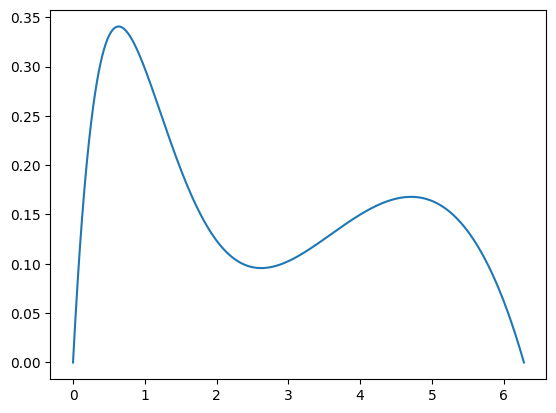

In [4]:
x = np.linspace(0, 2*np.pi, 1000)
plt.plot(x, mu_0_mixed(x))
plt.show()

## Benedetto et al. (1998)

Consider $G(x) = \beta \frac{(x-\pi)^2}{2}$ and $W(x) = \lambda |x-\pi|^3$ over the interval $[0, 2\pi]$. 

The McKean-Vlasov equation with these functions is the homogeneous version of the transport equation in a thermal bath with temperature $\beta^{-1}$ that can be derived from inelastic collisions. 

In [3]:
G = lambda x: 5 * (x - np.pi)**2
W = lambda x: np.abs(x-np.pi)**3

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2

Solving the equation. 

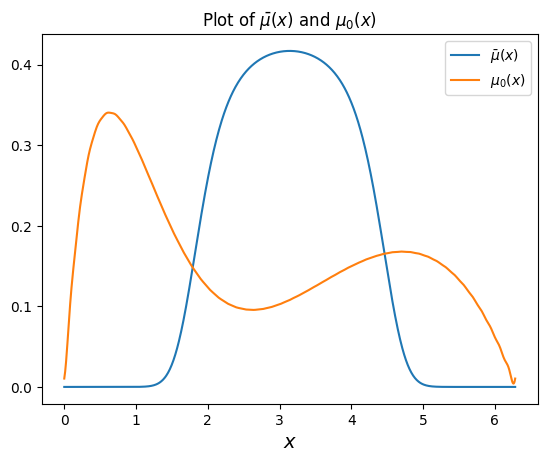

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.16.
MESSAGE - Nonlinear equation solved in 5.78.


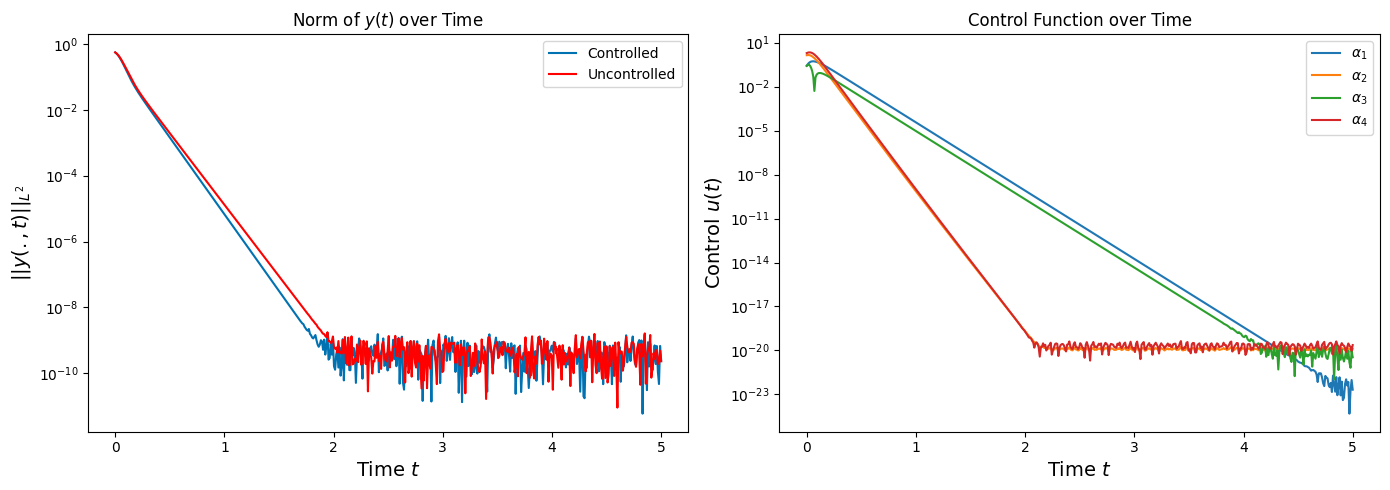

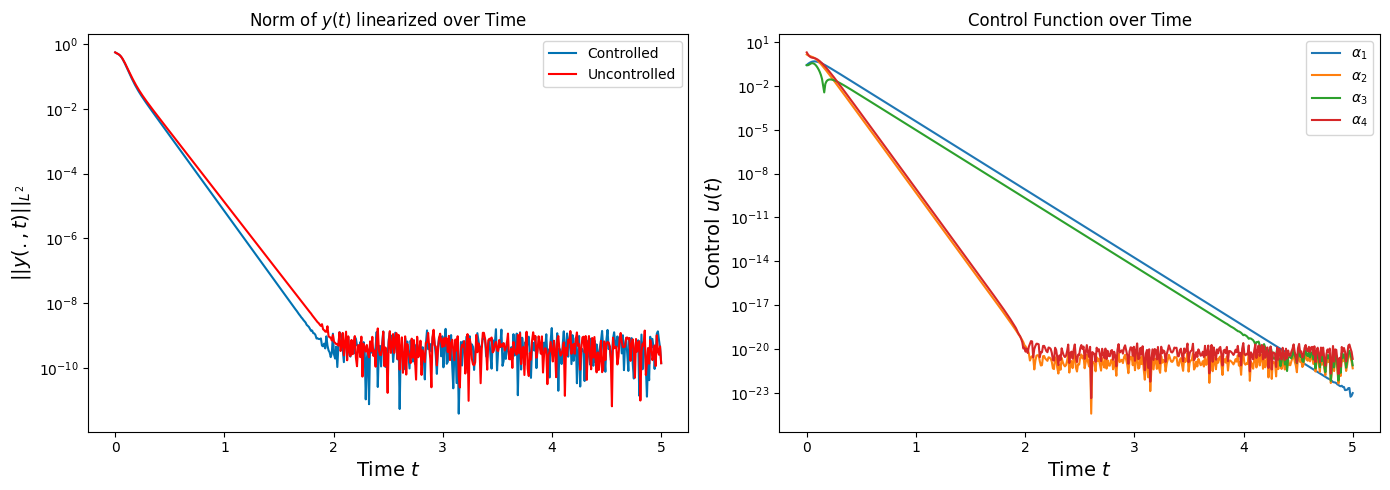

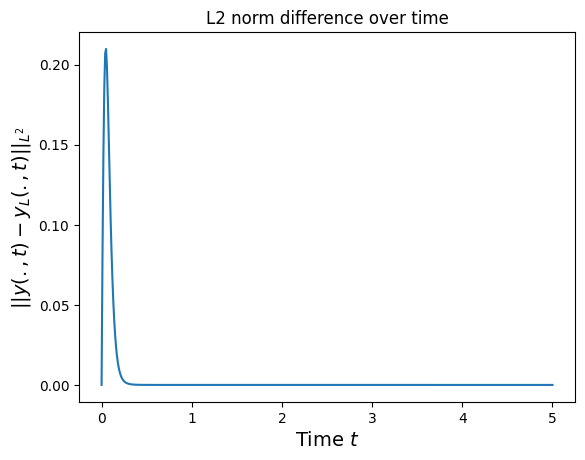

In [4]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

Consider now a smaller value of $\beta$ (so a higher temperature). 

In [5]:
G = lambda x: 1e-8 * (x - np.pi)**2

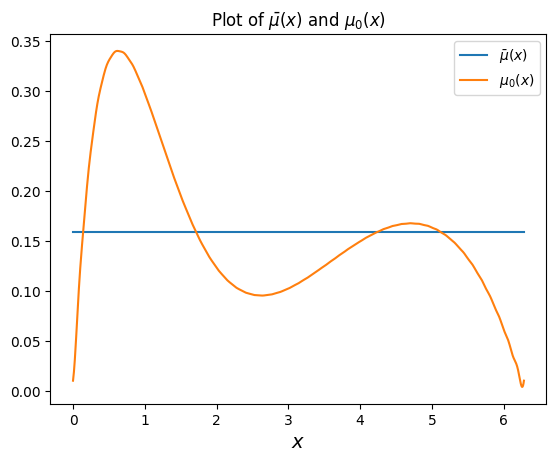

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.15.
MESSAGE - Nonlinear equation solved in 5.93.


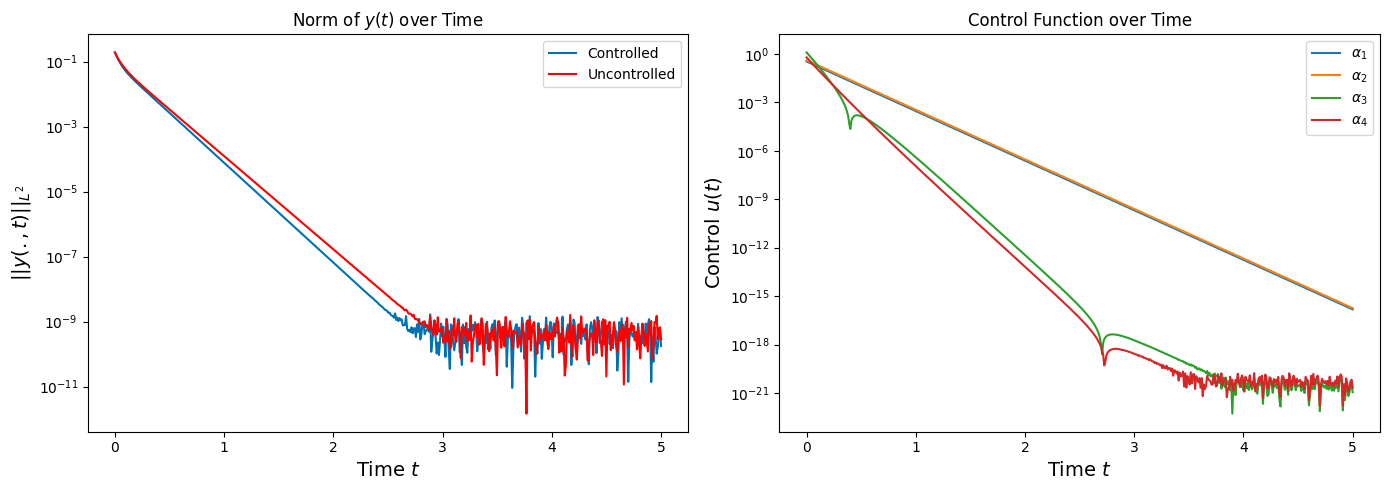

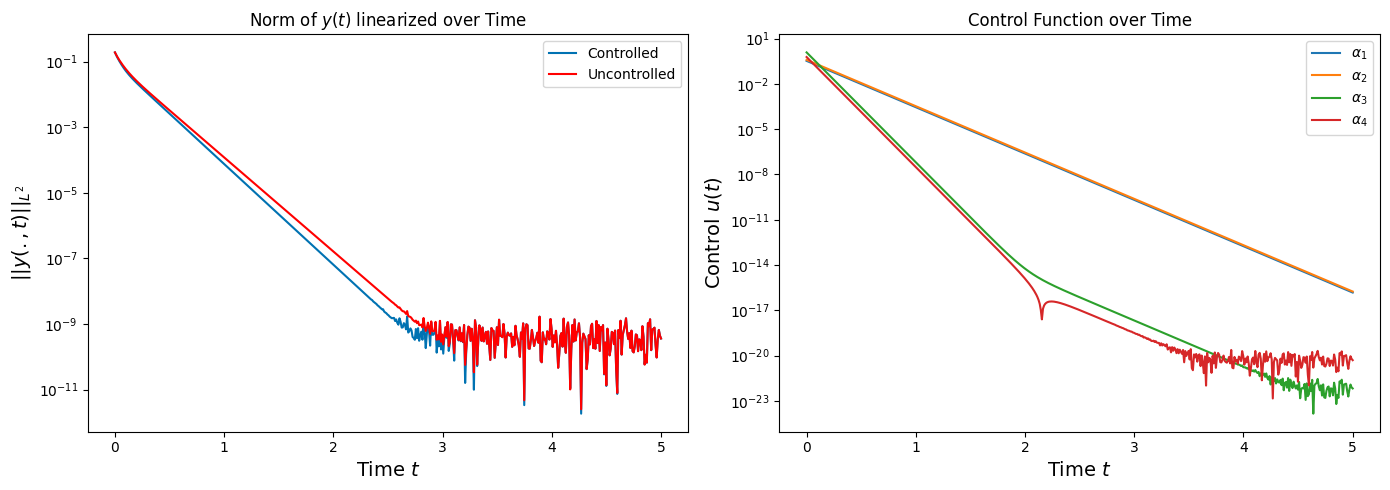

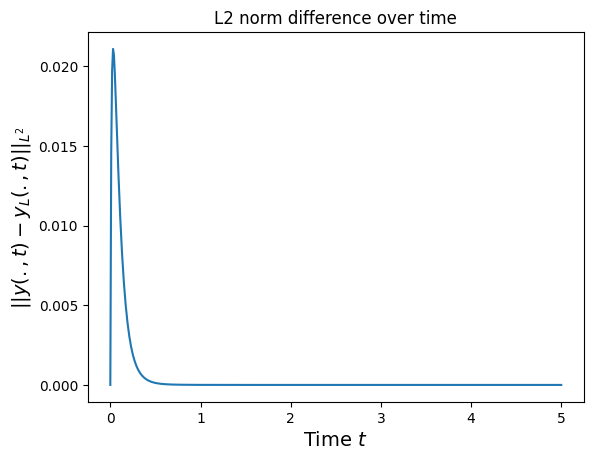

In [6]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

## Kuramoto model

Consider $G(x) = 0$ and $W(x) = -K \cos(x)$. First, $K = 1$. 

In [6]:
G = lambda x: np.zeros_like(x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

In [17]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

plotter = McKeanVlasovPlotter(solver)

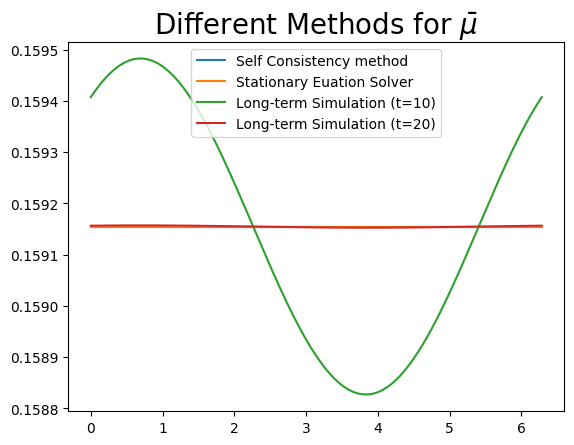

In [18]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 20), t_eval=(10, 20,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=10)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=20)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

For this example, we expect the density to converge to the uniform distribution. By using control on the linearsed equation, we can accelerate this convergence. Here, for example, in 2 seconds, we achieve the L2 norm of $10^{-9}$, while without control we would get something higher than $10^{-3}$. 

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.13.
MESSAGE - Nonlinear equation solved in 6.34.


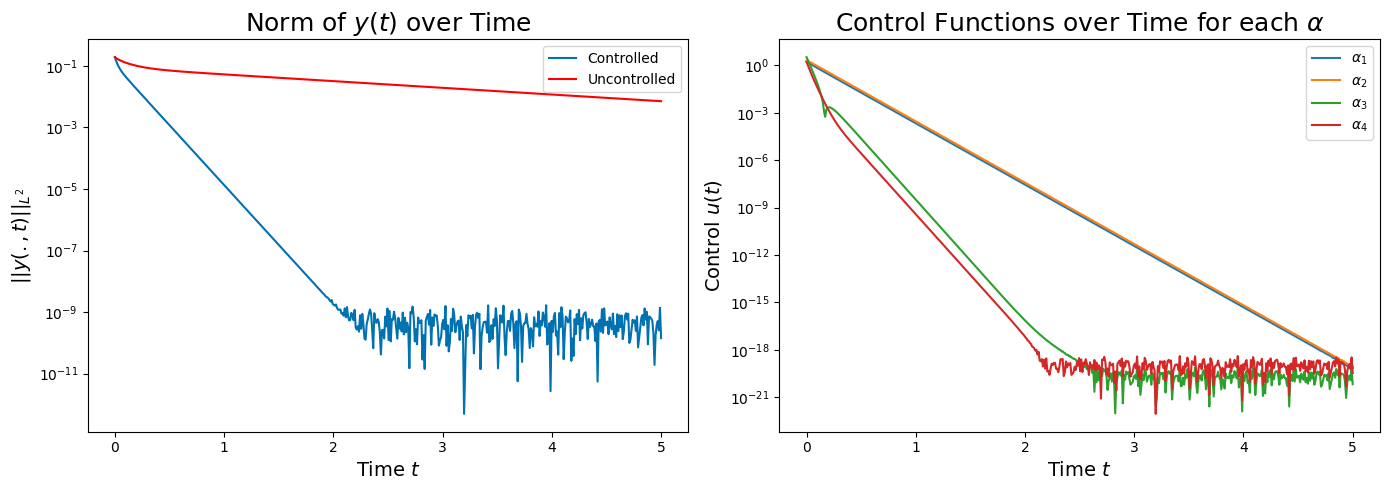

In [19]:
plotter.plot_control_and_norm(t_max=5.0)

For $K=5$, the situation is different. There is the presence of a second stationary distribution and the uniform one turns out to be unstable. Let's see what is means to linearise around the **unstable** steady state. 

In [21]:
G = lambda x: np.zeros_like(x)
W = lambda x: -5*np.cos(x)

solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

plotter = McKeanVlasovPlotter(solver)

Notice that the methods disagree on the solution, which was something possible as discussed. For this case, the convergence to the **stable** steady state is very fast.

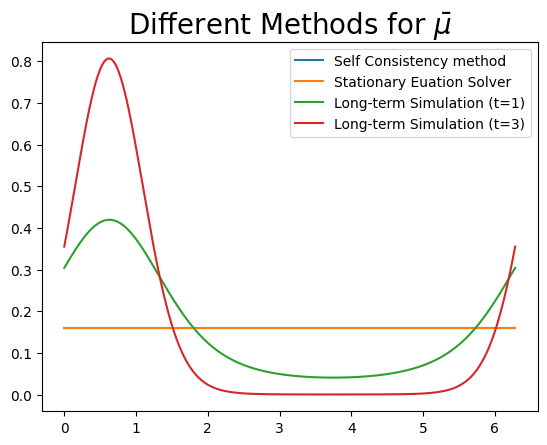

In [25]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 3), t_eval=(1, 3,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=1)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=3)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Controlling the equation leads to a situation where we are able to bring the solution close to the unstable steady state.

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.19.
MESSAGE - Nonlinear equation solved in 6.26.


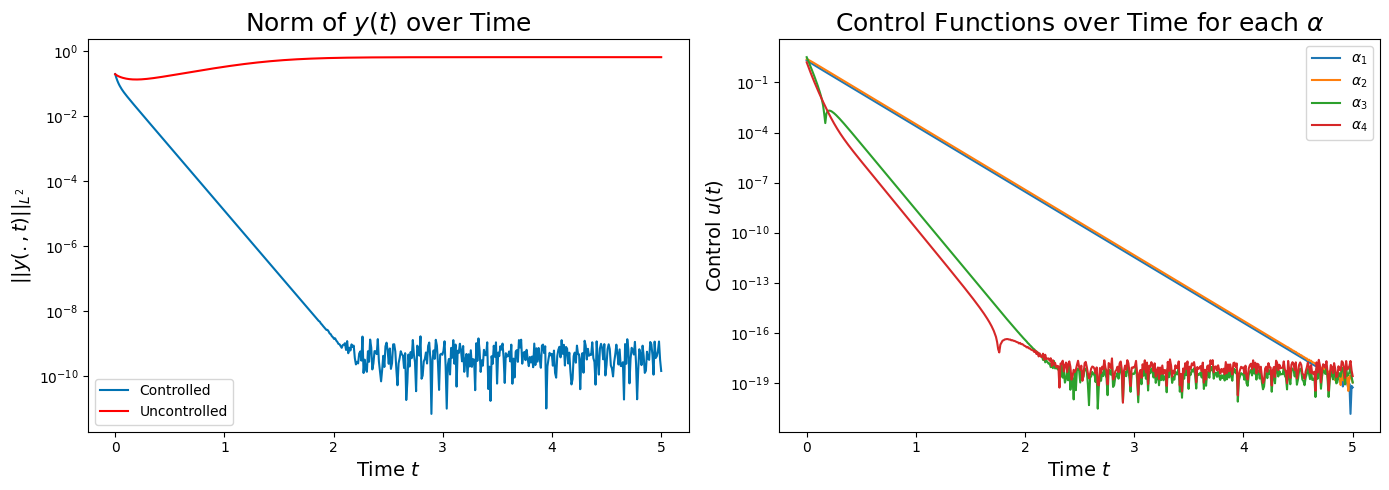

In [26]:
plotter.plot_control_and_norm(t_max=5.0)

## Kuramoto model + confining potential G

Let us change the model a little bit to include a non-zero potential $G$. 

$$
G(x) = cos(2x), W(x) = -cos(x)
$$

For $\sigma \ge 0.78$, we expect the single solution to be $\rho(x) = \exp(-cos(2x)/\sigma)$. For $\sigma < 0.77$, we have this solution plus other two with pick being at $\pi/2$ and $3\pi/2$.

Consider the example given in https://arxiv.org/pdf/2211.08004#page=7.23

In [6]:
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

Consider $\sigma = 0.78$. We expect a slow convergence.

In [7]:
sigma = 0.78

solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

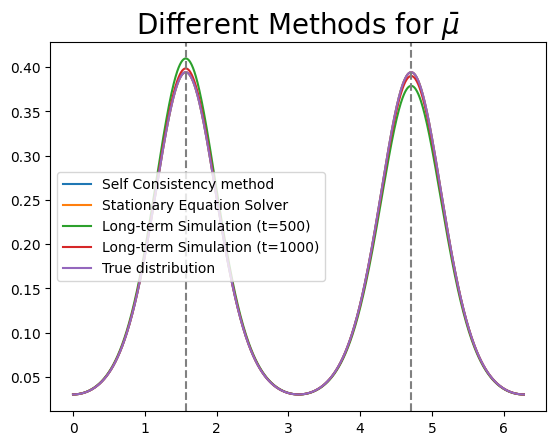

In [8]:
plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.plot(x, np.exp(-np.cos(2*x)/sigma) / np.trapezoid(np.exp(-np.cos(2*x)/sigma), x), label="True distribution")
plt.axvline(2*np.pi-np.pi/2, ls="--", c="gray")
plt.axvline(np.pi/2, ls="--", c="gray")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

For $\sigma < 0.77$, we know there will be other two stationary distributions

In [9]:
sigma = 0.6

solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

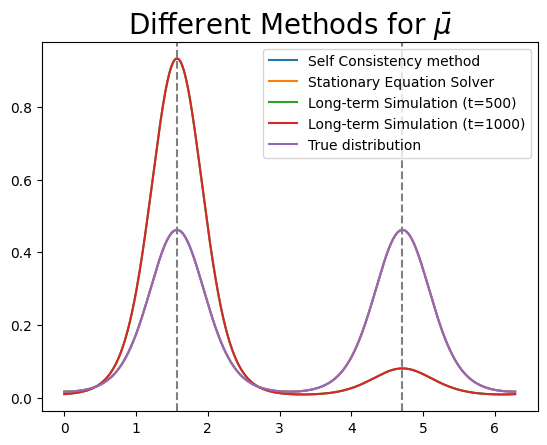

In [10]:
plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.plot(x, np.exp(-np.cos(2*x)/sigma) / np.trapezoid(np.exp(-np.cos(2*x)/sigma), x), label="True distribution")
plt.axvline(2*np.pi-np.pi/2, ls="--", c="gray")
plt.axvline(np.pi/2, ls="--", c="gray")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

## O(2) model with magnetic field

Now we consider a different model over $[0,1]$:

$G(x) = -\eta cos(2\pi x), W(x) = -cos(2\pi x)$.  

In [123]:
eta = 0.05
G = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma = 0.4678 # close to threshold
d = 1
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

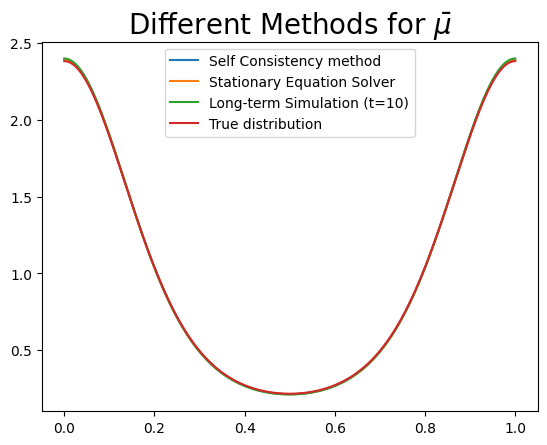

In [124]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 10), t_eval=(10,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(2*np.pi*x)) / np.trapezoid(np.exp(a*np.cos(2*np.pi*x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

A small modification over $[0,2\pi]$:

$G(x) = -\eta cos(x), W(x) = -cos(x)$.  

In [185]:
eta = 0.05
G = lambda x: -eta * np.cos(x)
W = lambda x: -np.cos(x)
sigma = 0.4678
d = 2*np.pi
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

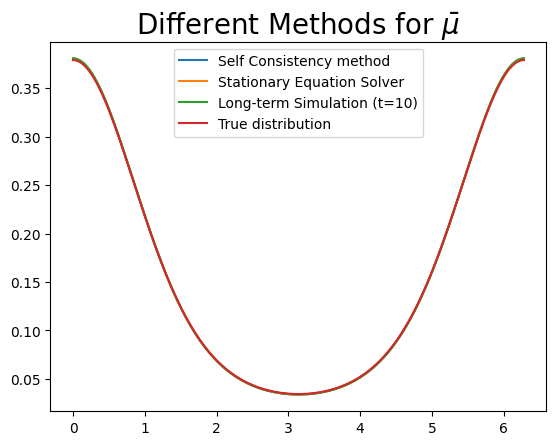

In [186]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(100,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(x)) / np.trapezoid(np.exp(a*np.cos(x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Another modification: 
$G(x) = -\eta cos(2x), W(x) = -Kcos(x)$.  

In this case, every stationary state has the form 

$$
\rho_{\infty}(x) \propto \exp\left(-\frac{1}{\sigma}(K r_1 \cos(x) + \eta \cos(2x))\right)
$$

### -> There is a point of problem here to analyse better. The negative sign poses a problem

In [264]:
eta = 0.5
K = 1.62
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -K * np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

In [290]:
def simulate_mckean_vlasov_torus(eta, K, N=2000, T=20.0, dt=0.01, sigma=1.0, seed=42):
    np.random.seed(seed)
    num_steps = int(T / dt)

    # Initialize particles on [0, 2π)
    X = np.random.uniform(0, 2 * np.pi, N)

    sqrt_2sigma_dt = np.sqrt(2 * sigma * dt)

    for step in tqdm(range(num_steps), desc="Simulating"):
        # Compute gradients
        gradV = 2 * eta * np.sin(2 * X)
        delta = (X[:, None] - X[None, :]+np.pi) % (2 * np.pi) - np.pi
        gradW = K * np.sin(delta)
        sum_gradW = gradW.mean(axis=1)

        # Euler-Maruyama update
        X += (-gradV - sum_gradW) * dt + sqrt_2sigma_dt * np.random.randn(N)
        X %= 2 * np.pi  # Periodic boundary

    return X

final_samples = simulate_mckean_vlasov_torus(eta=eta, K=K)

Simulating: 100%|███████████████████████████| 2000/2000 [01:28<00:00, 22.72it/s]


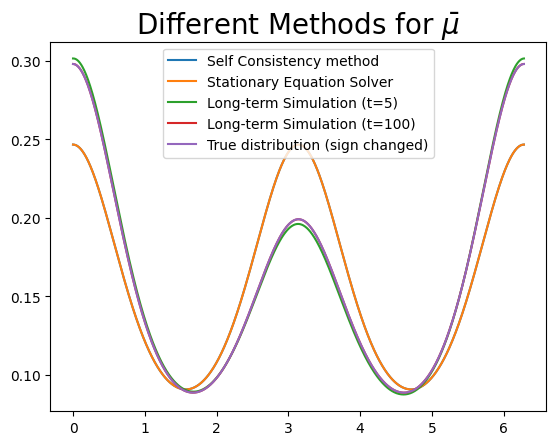

In [271]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(5, 100,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

r1 = np.trapezoid(np.cos(x)*mu_bar3_2, x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=5)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=100)")
plt.plot(x, np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)) / np.trapezoid(np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)), x),
         label="True distribution (sign changed)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

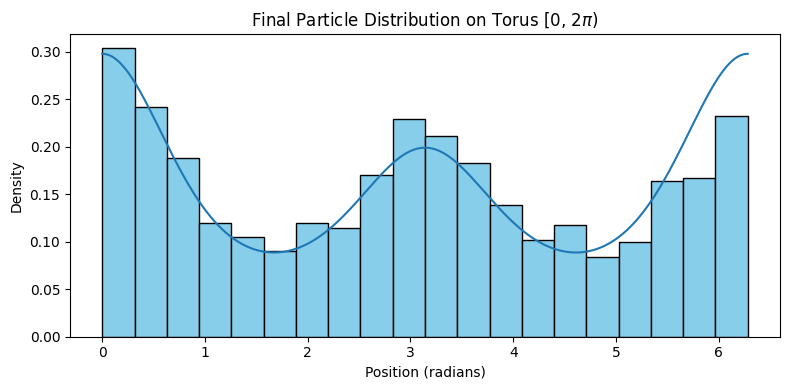

In [292]:
plt.figure(figsize=(8, 4))
plt.hist(final_samples, bins=20, density=True, color='skyblue', edgecolor='black')
plt.plot(x, mu_bar3_2)
plt.title("Final Particle Distribution on Torus [0, $2\pi$)")
plt.xlabel("Position (radians)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [245]:
eta = 0.5
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -1.6*np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

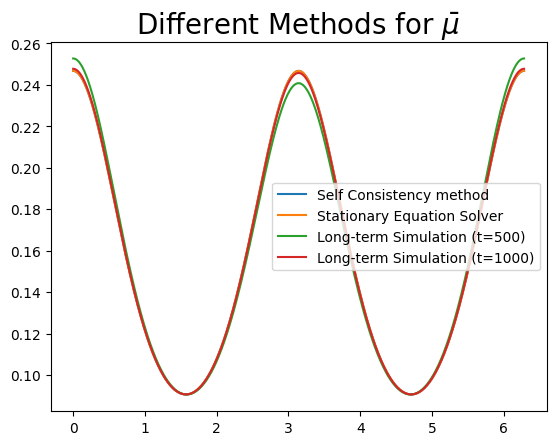

In [246]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

## Adding the controller

In [ ]:
eta = 0.05
G = lambda x: -eta * np.cos(x)
W = lambda x: -np.cos(x)
sigma = 0.4678
d = 2*np.pi